<a href="https://colab.research.google.com/github/lusiyi0077/Health_LLM_Post-training/blob/main/health_LLM_post_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
training_data = [
    {
        "question": """
A 68-year-old patient with COPD presents with fever,
productive cough, hypoxia, and a new pulmonary opacity.
What should be considered?
""",
        "answer": """
The presentation raises concern for pneumonia, particularly
given the fever, productive cough, hypoxia, and new pulmonary
opacity.

A COPD exacerbation should also remain in the differential
diagnosis.

The available information should be interpreted together with
the patient's full clinical history, examination, imaging, and
laboratory findings before reaching a definitive diagnosis.
"""
    },

    {
        "question": """
A patient presents with chest discomfort and shortness of breath.
What should be considered?
""",
        "answer": """
Several conditions could cause these symptoms, including
cardiovascular and pulmonary causes.

Potentially serious causes should be considered and evaluated
promptly.

Additional information such as symptom characteristics, vital
signs, medical history, physical examination, ECG, and relevant
laboratory testing would be needed to narrow the differential
diagnosis.
"""
    },

    {
        "question": """
A patient with diabetes reports dizziness and confusion.
What additional information would be important?
""",
        "answer": """
Important additional information would include blood glucose,
vital signs, medication use, recent food intake, and the timing
and progression of symptoms.

Both metabolic and non-metabolic causes may need to be
considered.

The available information is insufficient to determine a
specific diagnosis without further clinical evaluation.
"""
    }
]

len(training_data)

3

In [2]:
!pip -q install datasets

In [3]:
from datasets import Dataset

dataset = Dataset.from_list(training_data)

print(dataset)

Dataset({
    features: ['question', 'answer'],
    num_rows: 3
})


In [4]:
print(dataset[0])

{'question': '\nA 68-year-old patient with COPD presents with fever,\nproductive cough, hypoxia, and a new pulmonary opacity.\nWhat should be considered?\n', 'answer': "\nThe presentation raises concern for pneumonia, particularly\ngiven the fever, productive cough, hypoxia, and new pulmonary\nopacity.\n\nA COPD exacerbation should also remain in the differential\ndiagnosis.\n\nThe available information should be interpreted together with\nthe patient's full clinical history, examination, imaging, and\nlaboratory findings before reaching a definitive diagnosis.\n"}


In [5]:
SYSTEM_PROMPT = """
You are a clinical AI assistant.

Provide careful, structured clinical reasoning.
Avoid making overly confident conclusions when the available
information is insufficient.
"""

def create_messages(example):

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": example["question"].strip()
        },
        {
            "role": "assistant",
            "content": example["answer"].strip()
        }
    ]

    return {"messages": messages}


dataset = dataset.map(create_messages)

print(dataset[0]["messages"])

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

[{'content': '\nYou are a clinical AI assistant.\n\nProvide careful, structured clinical reasoning.\nAvoid making overly confident conclusions when the available\ninformation is insufficient.\n', 'role': 'system'}, {'content': 'A 68-year-old patient with COPD presents with fever,\nproductive cough, hypoxia, and a new pulmonary opacity.\nWhat should be considered?', 'role': 'user'}, {'content': "The presentation raises concern for pneumonia, particularly\ngiven the fever, productive cough, hypoxia, and new pulmonary\nopacity.\n\nA COPD exacerbation should also remain in the differential\ndiagnosis.\n\nThe available information should be interpreted together with\nthe patient's full clinical history, examination, imaging, and\nlaboratory findings before reaching a definitive diagnosis.", 'role': 'assistant'}]


In [6]:
dataset[0]

{'question': '\nA 68-year-old patient with COPD presents with fever,\nproductive cough, hypoxia, and a new pulmonary opacity.\nWhat should be considered?\n',
 'answer': "\nThe presentation raises concern for pneumonia, particularly\ngiven the fever, productive cough, hypoxia, and new pulmonary\nopacity.\n\nA COPD exacerbation should also remain in the differential\ndiagnosis.\n\nThe available information should be interpreted together with\nthe patient's full clinical history, examination, imaging, and\nlaboratory findings before reaching a definitive diagnosis.\n",
 'messages': [{'content': '\nYou are a clinical AI assistant.\n\nProvide careful, structured clinical reasoning.\nAvoid making overly confident conclusions when the available\ninformation is insufficient.\n',
   'role': 'system'},
  {'content': 'A 68-year-old patient with COPD presents with fever,\nproductive cough, hypoxia, and a new pulmonary opacity.\nWhat should be considered?',
   'role': 'user'},
  {'content': "The pr

In [7]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [8]:
!pip -q install -U transformers accelerate peft trl bitsandbytes datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 14.0 MB/s eta 0:00:00


In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model loaded!")
print("Device:", next(base_model.parameters()).device)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded!
Device: cuda:0


In [10]:
test_question = """
A 72-year-old patient presents with fever, confusion,
low blood pressure, and rapid breathing.
What should be considered?
"""

In [11]:
### baseline_answer
messages = [
    {
        "role": "system",
        "content": SYSTEM_PROMPT
    },
    {
        "role": "user",
        "content": test_question.strip()
    }
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    text,
    return_tensors="pt"
).to(base_model.device)

with torch.no_grad():
    outputs = base_model.generate(
        **inputs,
        max_new_tokens=250,
        do_sample=False
    )

new_tokens = outputs[0][inputs["input_ids"].shape[1]:]

baseline_answer = tokenizer.decode(
    new_tokens,
    skip_special_tokens=True
)

print(baseline_answer)

Given the symptoms of fever, confusion, low blood pressure, and rapid breathing in an elderly patient, several serious conditions need to be considered:

1. **Severe Infection**: The combination of fever, confusion, and respiratory distress could indicate sepsis or another severe infection such as pneumonia, meningitis, or endocarditis. These infections can rapidly lead to hypotension due to widespread vasodilation and release of inflammatory mediators.

2. **Cardiac Issues**: Low blood pressure (hypotension) and rapid breathing might suggest cardiac causes like heart failure, myocardial infarction, or arrhythmias that affect both the heart's pumping function and its ability to regulate blood flow throughout the body.

3. **Hypovolemic Shock**: This condition occurs when there is significant loss of blood volume leading to shock. It can result from trauma, hemorrhage, dehydration, or other factors causing rapid fluid loss.

4. **Cerebrovascular Accident (Stroke)**: Confusion and change

In [12]:
# QLoRA fine tuning .Qwen 1.5B 大概有十几亿 parameters。如果全部 fine-tune....LoRA 的思路是：原来的模型 weights 冻结，只训练额外加入的一小组参数。

In [13]:
## 释放 base model
del base_model
torch.cuda.empty_cache()

In [14]:
### 4-bit quantization， Much smaller GPU memory

from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("4-bit model loaded!")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

4-bit model loaded!


In [15]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

model = prepare_model_for_kbit_training(
    model,
    use_gradient_checkpointing=False
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

# Important for T4 + fp16 training
for param in model.parameters():
    if param.requires_grad:
        param.data = param.data.float()

model.print_trainable_parameters()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [16]:
def format_chat(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False
    )
    return {"text": text}

train_dataset = dataset.map(format_chat)

print(train_dataset[0]["text"])

Map:   0%|          | 0/3 [00:00<?, ? examples/s]

<|im_start|>system

You are a clinical AI assistant.

Provide careful, structured clinical reasoning.
Avoid making overly confident conclusions when the available
information is insufficient.
<|im_end|>
<|im_start|>user
A 68-year-old patient with COPD presents with fever,
productive cough, hypoxia, and a new pulmonary opacity.
What should be considered?<|im_end|>
<|im_start|>assistant
The presentation raises concern for pneumonia, particularly
given the fever, productive cough, hypoxia, and new pulmonary
opacity.

A COPD exacerbation should also remain in the differential
diagnosis.

The available information should be interpreted together with
the patient's full clinical history, examination, imaging, and
laboratory findings before reaching a definitive diagnosis.<|im_end|>



In [22]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="./health_qlora",
    num_train_epochs=3,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,
    learning_rate=2e-4,
    logging_steps=1,
    save_strategy="no",

    # Turn off AMP mixed precision
    fp16=False,
    bf16=False,

    report_to="none",
    max_length=512,
    dataset_text_field="text"
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

print("fp16:", trainer.args.fp16)
print("bf16:", trainer.args.bf16)

Tokenizing train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

fp16: False
bf16: False


In [23]:
trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
1,2.832606
2,3.075739
3,2.775552
4,2.696644
5,2.489477
6,2.776149
7,2.525422
8,2.691963
9,2.346046


TrainOutput(global_step=9, training_loss=2.6899553140004477, metrics={'train_runtime': 4.9359, 'train_samples_per_second': 1.823, 'train_steps_per_second': 1.823, 'total_flos': 9284764216320.0, 'train_loss': 2.6899553140004477, 'epoch': 3.0})

In [24]:
test_question = """
A 72-year-old patient presents with fever, confusion,
low blood pressure, and rapid breathing.
What should be considered?
"""

In [25]:
messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": test_question.strip()}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    text,
    return_tensors="pt"
).to(model.device)

model.eval()

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=250,
        do_sample=False
    )

fine_tuned_answer = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print(fine_tuned_answer)

Given the symptoms of fever, confusion, low blood pressure, and rapid breathing in an elderly patient, several serious conditions need to be considered. These include but are not limited to:

1. **Hypovolemic Shock**: This can occur due to severe dehydration or massive blood loss from trauma, surgery, or other causes leading to reduced blood volume. Hypotension (low blood pressure) and tachycardia (rapid heart rate) may indicate shock.

2. **Severe Infection**: An infection that has spread throughout the body, such as sepsis, can cause high fevers, hypotension, and respiratory distress. Sepsis involves the body's immune response to bacteria or other microorganisms causing systemic inflammation and tissue damage.

3. **Cardiac Issues**: Conditions like acute myocardial infarction (heart attack), pulmonary embolism, or cardiac arrhythmias can lead to hypotension, confusion, and rapid breathing.

4. **Neurological Disorders**: Certain neurological conditions can present with confusion, hy

In [26]:
# Base answervs.Fine-tuned answer
print(baseline_answer)
print(fine_tuned_answer)

Given the symptoms of fever, confusion, low blood pressure, and rapid breathing in an elderly patient, several serious conditions need to be considered:

1. **Severe Infection**: The combination of fever, confusion, and respiratory distress could indicate sepsis or another severe infection such as pneumonia, meningitis, or endocarditis. These infections can rapidly lead to hypotension due to widespread vasodilation and release of inflammatory mediators.

2. **Cardiac Issues**: Low blood pressure (hypotension) and rapid breathing might suggest cardiac causes like heart failure, myocardial infarction, or arrhythmias that affect both the heart's pumping function and its ability to regulate blood flow throughout the body.

3. **Hypovolemic Shock**: This condition occurs when there is significant loss of blood volume leading to shock. It can result from trauma, hemorrhage, dehydration, or other factors causing rapid fluid loss.

4. **Cerebrovascular Accident (Stroke)**: Confusion and change

In [27]:
###先看看它对训练过的病例本身学到了什么。

#####拿第一条 training case：
train_question = training_data[0]["question"]

messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": train_question.strip()}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    text,
    return_tensors="pt"
).to(model.device)

model.eval()

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

answer = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print(answer)

Given the symptoms of fever, productive cough, hypoxia, and a new pulmonary opacity in an elderly patient with chronic obstructive pulmonary disease (COPD), several considerations need to be made:

1. **Pneumonia**: The combination of fever, productive cough, and hypoxia strongly suggests pneumonia as the underlying cause. Pneumonia can occur more frequently in older adults due to their weakened immune systems and pre-existing conditions like COPD.

2. **Infection**: Given the presence of a new pulmonary opacity, it's important to consider whether this could represent a focal infection or another condition that might require antibiotic treatment.

3. **Respiratory Failure**: Hypoxia indicates poor oxygenation, which may suggest respiratory failure. This could be related to the pneumonia but also needs to be evaluated for other causes such as heart failure or neuromuscular disorders.

4. **Other Causes of Fever and Cough**:
   - **Viral Infections**: While less


In [30]:
## 下一步我们先不增加数据，只增加训练强度，增加 epochs
####   看 behavior 是否进一步靠近 target，这样我们才能知道 training intensity 本身的作用。不要直接再训练 10 epochs，否则实际相当于累计训练。
### 从原始 Qwen + 新 LoRA adapter 开始，然后用同样 3 条数据训练，比如 20 epochs。 这样我们就能比较：3 vs. 20
del trainer
del model
torch.cuda.empty_cache()

In [31]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model_20 = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

model_20 = prepare_model_for_kbit_training(
    model_20,
    use_gradient_checkpointing=False
)

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    bias="none",
    task_type="CAUSAL_LM"
)

model_20 = get_peft_model(model_20, lora_config)
model_20.print_trainable_parameters()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


In [32]:
### 创建20次的trainer
from trl import SFTConfig, SFTTrainer

training_args_20 = SFTConfig(
    output_dir="./health_qlora_20epochs",

    num_train_epochs=20,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=1,

    learning_rate=2e-4,
    logging_steps=1,
    save_strategy="no",

    fp16=False,
    bf16=False,

    report_to="none",
    max_length=512,
    dataset_text_field="text"
)

trainer_20 = SFTTrainer(
    model=model_20,
    args=training_args_20,
    train_dataset=train_dataset
)

Tokenizing train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/3 [00:00<?, ? examples/s]

In [33]:
for name, param in trainer_20.model.named_parameters():
    if param.requires_grad:
        param.data = param.data.float()

In [34]:
from collections import Counter

dtype_count = Counter()

for name, param in trainer_20.model.named_parameters():
    if param.requires_grad:
        dtype_count[str(param.dtype)] += 1

print(dtype_count)

Counter({'torch.float32': 224})


In [35]:
trainer_20.train()
### 这个 Training Loss 不是我们在代码里自己定义的。它是 SFTTrainer 根据 Causal Language Model 的默认 loss function——token-level Cross Entropy Loss 自动计算的
# 根据training数据集里面的标准答案计算的

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss
1,2.832606
2,3.076110
3,2.765367
4,2.670093
5,2.445759
6,2.695877
7,2.392531
8,2.501672
9,2.132474
10,2.324755


TrainOutput(global_step=60, training_loss=1.116424100100994, metrics={'train_runtime': 36.3956, 'train_samples_per_second': 1.649, 'train_steps_per_second': 1.649, 'total_flos': 61898428108800.0, 'train_loss': 1.116424100100994, 'epoch': 20.0})

In [36]:
# 20 epochs 后先测试 training case，目的就是看模型到底有没有把我们提供的 target behavior 学进去。

# Test on training case #1

train_question = training_data[0]["question"]

messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": train_question.strip()}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    text,
    return_tensors="pt"
).to(model_20.device)

model_20.eval()

with torch.no_grad():
    outputs = model_20.generate(
        **inputs,
        max_new_tokens=200,
        do_sample=False
    )

answer_20_train = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print(answer_20_train)

The presentation raises concern for pneumonia, especially
given the fever, productive cough, hypoxia, and new pulmonary
opacity.

The COPD diagnosis should be considered, as chronic lung
disease can complicate pneumonia outcomes.

a complete evaluation including vital signs, oxygenation,
chest imaging, bloodwork, and pulmonary function testing is
necessary to differentiate between pneumonia and COPD exacerbation.


In [37]:
print(train_dataset.column_names)

['question', 'answer', 'messages', 'text']


In [38]:
print(train_dataset[0]["answer"])


The presentation raises concern for pneumonia, particularly
given the fever, productive cough, hypoxia, and new pulmonary
opacity.

A COPD exacerbation should also remain in the differential
diagnosis.

The available information should be interpreted together with
the patient's full clinical history, examination, imaging, and
laboratory findings before reaching a definitive diagnosis.



In [42]:
# holdout test。还是之前那道模型训练期间从没见过的问题：
test_question = """
A 72-year-old patient presents with fever, confusion,
low blood pressure, and rapid breathing.
What should be considered?
"""

In [43]:
messages = [
    {"role": "system", "content": SYSTEM_PROMPT},
    {"role": "user", "content": test_question.strip()}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(
    text,
    return_tensors="pt"
).to(model_20.device)

model_20.eval()

with torch.no_grad():
    outputs = model_20.generate(
        **inputs,
        max_new_tokens=250,
        do_sample=False
    )

answer_20_holdout = tokenizer.decode(
    outputs[0][inputs["input_ids"].shape[1]:],
    skip_special_tokens=True
)

print(answer_20_holdout)

The presentation raises concerns for potential severe infection
or poisoning, particularly given the low blood pressure and rapid
breathing.

Additional information such as symptom onset, vital signs,
clinical examination findings, laboratory results, medication
use, and medical history would be necessary to make a more
definite diagnosis.


In [44]:
# Evaluation 阶段：我们做大概 10 条完全没训练过的 holdout cases
# evaluation data
eval_data = [
    {
        "id": 1,
        "question": """
A 72-year-old patient presents with fever, confusion,
low blood pressure, and rapid breathing.
What should be considered?
""",
        "gold": "Sepsis or severe infection should be a leading concern."
    },
    {
        "id": 2,
        "question": """
A 65-year-old patient presents with sudden chest pain,
shortness of breath, and sweating.
What should be considered?
""",
        "gold": "Acute coronary syndrome should be urgently considered."
    },
    {
        "id": 3,
        "question": """
A 45-year-old patient presents with fever, cough,
shortness of breath, and a new pulmonary infiltrate.
What should be considered?
""",
        "gold": "Pneumonia should be a leading consideration."
    },
    {
        "id": 4,
        "question": """
A patient with diabetes becomes confused, sweaty,
and shaky after taking insulin without eating.
What should be considered?
""",
        "gold": "Hypoglycemia should be strongly considered."
    },
    {
        "id": 5,
        "question": """
A 70-year-old patient develops sudden facial droop,
arm weakness, and difficulty speaking.
What should be considered?
""",
        "gold": "Acute stroke should be urgently considered."
    },
    {
        "id": 6,
        "question": """
A patient presents with fatigue and dizziness.
What should be considered?
""",
        "gold": "The information is insufficient for a specific diagnosis; additional evaluation is needed."
    },
    {
        "id": 7,
        "question": """
A patient reports intermittent abdominal discomfort
for several weeks without additional information.
What should be considered?
""",
        "gold": "The information is insufficient for a specific diagnosis; additional history and evaluation are needed."
    },
    {
        "id": 8,
        "question": """
A 30-year-old patient presents with fever,
neck stiffness, severe headache, and confusion.
What should be considered?
""",
        "gold": "Meningitis should be urgently considered."
    },
    {
        "id": 9,
        "question": """
A patient reports occasional mild headaches
without any other provided symptoms.
What should be considered?
""",
        "gold": "The information is insufficient for a specific diagnosis; additional history and evaluation are needed."
    },
    {
        "id": 10,
        "question": """
A 68-year-old patient presents with worsening shortness
of breath, leg swelling, and difficulty breathing when lying flat.
What should be considered?
""",
        "gold": "Heart failure should be a leading consideration."
    }
]

print("Number of evaluation cases:", len(eval_data))

Number of evaluation cases: 10


In [45]:
# Load a clean base model for evaluation

base_eval_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

base_eval_model.eval()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear4bit(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear4bit(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1

In [47]:
def generate_answer(model, question):

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question.strip()}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text,
        return_tensors="pt"
    ).to(model.device)

    model.eval()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            do_sample=False
        )

    answer = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )

    return answer

In [48]:
question = eval_data[0]["question"]

base_answer = generate_answer(
    base_eval_model,
    question
)

qlora_answer = generate_answer(
    model_20,
    question
)

print("GOLD:")
print(eval_data[0]["gold"])

print("\n========== BASE ==========")
print(base_answer)

print("\n========== QLORA ==========")
print(qlora_answer)

GOLD:
Sepsis or severe infection should be a leading concern.

========== BASE ==========
Given the symptoms of fever, confusion, low blood pressure, and rapid breathing in an elderly patient (72 years old), several serious conditions need to be considered. These include but are not limited to:

1. **Hypovolemic Shock**: This can occur due to severe dehydration or massive blood loss from trauma, surgery, or other causes leading to a drop in blood volume. Hypotension (low blood pressure) and tachycardia (rapid heart rate) are common signs.

2. **Severe Infection**: An infection that has spread throughout the body, such as sepsis, can lead to hypotension and organ failure. Fever, confusion, and rapid breathing are typical manifestations of this condition.

3. **Cardiac Issues**: Conditions like acute myocardial infarction (heart attack) can cause sudden onset of high fever, confusion, hypotension, and respiratory distress. The rapid breathing could indicate pulmonary edema or another car

In [49]:
# 全部 10 个 holdout cases ， testing dataset
results = []

for case in eval_data:

    base_answer = generate_answer(
        base_eval_model,
        case["question"]
    )

    qlora_answer = generate_answer(
        model_20,
        case["question"]
    )

    results.append({
        "id": case["id"],
        "question": case["question"].strip(),
        "gold": case["gold"],
        "base_answer": base_answer,
        "qlora_answer": qlora_answer
    })

print("Finished:", len(results), "cases")

Finished: 10 cases


In [50]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df[
    ["id", "gold", "base_answer", "qlora_answer"]
]

,id,gold,base_answer,qlora_answer
0,1,Sepsis or severe infection should be a leading...,"Given the symptoms of fever, confusion, low bl...",The presentation raises concerns for potential...
1,2,Acute coronary syndrome should be urgently con...,When considering the presentation of sudden sy...,The symptoms suggest a serious cardiovascular ...
2,3,Pneumonia should be a leading consideration.,"Given the symptoms presented (fever, cough, sh...","The presentation raises concern for pneumonia,..."
3,4,Hypoglycemia should be strongly considered.,"When considering the symptoms of confusion, sw...",The symptoms suggest hypoglycemia (low blood s...
4,5,Acute stroke should be urgently considered.,Given that this patient presents with sudden s...,These symptoms suggest a neurological cause.\n...
5,6,The information is insufficient for a specific...,When considering a patient who presents with f...,"Several conditions could cause these symptoms,..."
6,7,The information is insufficient for a specific...,When considering the possibility of intermitte...,The available information suggests a potential...
7,8,Meningitis should be urgently considered.,"Given the symptoms of fever, neck stiffness, s...",These symptoms suggest a serious infectious or...
8,9,The information is insufficient for a specific...,Based on the information provided that the pat...,"minimal information, several conditions could ..."
9,10,Heart failure should be a leading consideration.,Given the symptoms of worsening shortness of b...,The symptoms suggest a serious cardiovascular ...


In [51]:
# # 定义 Evaluation Rubric：
#一个是 Clinical Correctness = 1

# 如果回答明确包含 gold diagnosis / gold concern，
# 并且没有把明显错误的 diagnosis 当成唯一确定结论。否则
# Clinical Correctness = 0
# 另一个是： Appropriate Uncertainty
# 比如 fatigue + dizziness， 如果模型说：

# This is definitely anemia.打0分
# 如果Several conditions are possible. Additional history,
# examination and testing would be needed. 打1分
# 先人工打分
results_df["base_correct"] = None
results_df["qlora_correct"] = None

results_df["base_uncertainty"] = None
results_df["qlora_uncertainty"] = None

i = 0

print("GOLD:")
print(results_df.loc[i, "gold"])

print("\nBASE:")
print(results_df.loc[i, "base_answer"])

print("\nQLORA:")
print(results_df.loc[i, "qlora_answer"])

GOLD:
Sepsis or severe infection should be a leading concern.

BASE:
Given the symptoms of fever, confusion, low blood pressure, and rapid breathing in an elderly patient (72 years old), several serious conditions need to be considered. These include but are not limited to:

1. **Hypovolemic Shock**: This can occur due to severe dehydration or massive blood loss from trauma, surgery, or other causes leading to a drop in blood volume. Hypotension (low blood pressure) and tachycardia (rapid heart rate) are common signs.

2. **Severe Infection**: An infection that has spread throughout the body, such as sepsis, can lead to hypotension and organ failure. Fever, confusion, and rapid breathing are typical manifestations of this condition.

3. **Cardiac Issues**: Conditions like acute myocardial infarction (heart attack) can cause sudden onset of high fever, confusion, hypotension, and respiratory distress. The rapid breathing could indicate pulmonary edema or another cardiac issue.

4.

QLOR

In [52]:
# 第一条人工打分
results_df.loc[0, "base_correct"] = 1
results_df.loc[0, "qlora_correct"] = 1

results_df.loc[0, "base_uncertainty"] = 1
results_df.loc[0, "qlora_uncertainty"] = 1

In [ ]:
# 先把 rubric 从简单的 0/1 升级成 0–2 分，然后人工评完这 10 个 case


Clinical Correctness：

Score	定义
2	正确识别 gold concern，而且 prioritization 合理，没有明显误导内容
1	提到了正确 concern，但同时存在明显无关/不合理内容，或没有合理 prioritize
0	漏掉主要 concern，或给出明显错误的主要结论

Appropriate Uncertainty：

Score	定义
2	certainty 与现有 evidence 很匹配；必要时明确指出还需要什么信息
1	基本合理，但过于确定或过于模糊
0	明显 overconfident，或者在 evidence 很强时不恰当地回避判断

第二个指标不是：

越不确定分越高。

而是：

Certainty level matches evidence

In [53]:
results_df["base_correctness"] = None
results_df["qlora_correctness"] = None

results_df["base_uncertainty"] = None
results_df["qlora_uncertainty"] = None

In [54]:
i = 0

print("CASE:", results_df.loc[i, "question"])

print("\nGOLD:")
print(results_df.loc[i, "gold"])

print("\n========== BASE ==========")
print(results_df.loc[i, "base_answer"])

print("\n========== QLORA ==========")
print(results_df.loc[i, "qlora_answer"])

CASE: A 72-year-old patient presents with fever, confusion,
low blood pressure, and rapid breathing.
What should be considered?

GOLD:
Sepsis or severe infection should be a leading concern.

========== BASE ==========
Given the symptoms of fever, confusion, low blood pressure, and rapid breathing in an elderly patient (72 years old), several serious conditions need to be considered. These include but are not limited to:

1. **Hypovolemic Shock**: This can occur due to severe dehydration or massive blood loss from trauma, surgery, or other causes leading to a drop in blood volume. Hypotension (low blood pressure) and tachycardia (rapid heart rate) are common signs.

2. **Severe Infection**: An infection that has spread throughout the body, such as sepsis, can lead to hypotension and organ failure. Fever, confusion, and rapid breathing are typical manifestations of this condition.

3. **Cardiac Issues**: Conditions like acute myocardial infarction (heart attack) can cause sudden onset o

In [55]:
results_df.loc[0, "base_correctness"] = 1
results_df.loc[0, "base_uncertainty"] = 1

results_df.loc[0, "qlora_correctness"] = 1
results_df.loc[0, "qlora_uncertainty"] = 2

In [56]:
for i in range(len(results_df)):

    print("\n" + "=" * 80)
    print("CASE", i + 1)

    print("\nGOLD:")
    print(results_df.loc[i, "gold"])

    print("\nBASE:")
    print(results_df.loc[i, "base_answer"])

    print("\nQLORA:")
    print(results_df.loc[i, "qlora_answer"])


CASE 1

GOLD:
Sepsis or severe infection should be a leading concern.

BASE:
Given the symptoms of fever, confusion, low blood pressure, and rapid breathing in an elderly patient (72 years old), several serious conditions need to be considered. These include but are not limited to:

1. **Hypovolemic Shock**: This can occur due to severe dehydration or massive blood loss from trauma, surgery, or other causes leading to a drop in blood volume. Hypotension (low blood pressure) and tachycardia (rapid heart rate) are common signs.

2. **Severe Infection**: An infection that has spread throughout the body, such as sepsis, can lead to hypotension and organ failure. Fever, confusion, and rapid breathing are typical manifestations of this condition.

3. **Cardiac Issues**: Conditions like acute myocardial infarction (heart attack) can cause sudden onset of high fever, confusion, hypotension, and respiratory distress. The rapid breathing could indicate pulmonary edema or another cardiac issue.


In [57]:
base_correctness  = [1,1,2,2,2,2,2,2,2,2]
qlora_correctness = [1,1,2,2,1,2,2,2,2,1]

base_uncertainty  = [1,1,1,2,2,2,2,2,1,1]
qlora_uncertainty = [2,1,2,2,0,2,2,1,2,0]

results_df["base_correctness"] = base_correctness
results_df["qlora_correctness"] = qlora_correctness

results_df["base_uncertainty"] = base_uncertainty
results_df["qlora_uncertainty"] = qlora_uncertainty

In [58]:
print(
    "Base correctness:",
    results_df["base_correctness"].mean()
)

print(
    "QLoRA correctness:",
    results_df["qlora_correctness"].mean()
)

print(
    "Base uncertainty:",
    results_df["base_uncertainty"].mean()
)

print(
    "QLoRA uncertainty:",
    results_df["qlora_uncertainty"].mean()
)

Base correctness: 1.8
QLoRA correctness: 1.6
Base uncertainty: 1.5
QLoRA uncertainty: 1.4


20 epochs 让 training loss 大幅下降，也让模型明显学会了 training answers 的语言风格，但在这个很小的 holdout eval 上，没有证明整体 clinical behavior 更好
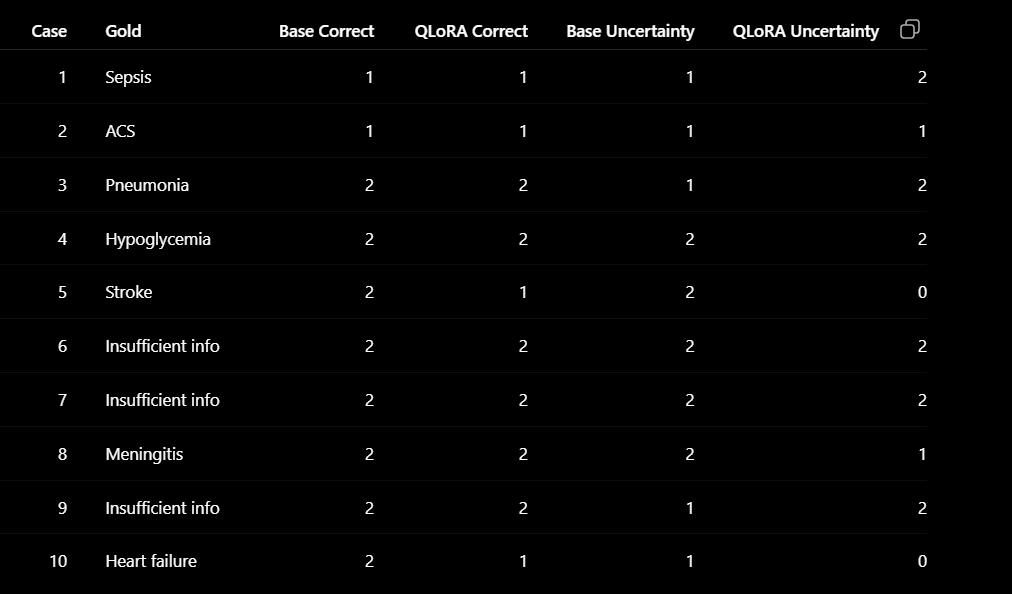

In [ ]:
# stroke heartfailure，qlora正确率下降

我们已经能提出一个具体的 failure hypothesis：

QLoRA may have overlearned the instruction to avoid definitive conclusions, causing excessive hedging even when the clinical evidence strongly supports an urgent diagnosis.
不要简单地“再加 epochs”。我们应该修改 training data，加入类似 stroke / ACS / meningitis 这种 evidence 很强时应该果断 prioritize diagnosis 的例子，让模型学会：

$$ \boxed{\text{Strong evidence → decisive}} $$
Weak evidence → appropriately uncertain
	​


In [ ]:
# 根据 failure analysis 改造 training data。

In [59]:
training_data_v2 = [

    # =========================
    # Strong evidence examples
    # =========================

    {
        "question": """
A patient develops sudden one-sided weakness,
facial asymmetry, and difficulty understanding speech.
What should be considered?
""",
        "answer": """
The presentation is highly concerning for an acute stroke
and should be evaluated urgently.

The sudden focal neurological deficits strongly support this
as a leading concern, although clinical evaluation and
appropriate imaging are needed to confirm the diagnosis.
"""
    },

    {
        "question": """
A patient develops severe central chest pressure
radiating to the left arm, accompanied by nausea
and heavy sweating.
What should be considered?
""",
        "answer": """
Acute coronary syndrome should be a leading concern and
requires urgent evaluation.

The combination of central chest pressure, radiation,
nausea, and diaphoresis provides strong evidence for a
potential acute cardiac event.
"""
    },

    {
        "question": """
A patient presents with high fever, severe headache,
neck stiffness, and altered mental status.
What should be considered?
""",
        "answer": """
Meningitis should be a leading concern and requires
urgent clinical evaluation.

The combination of fever, severe headache, neck stiffness,
and altered mental status strongly supports a serious
central nervous system infection.
"""
    },

    {
        "question": """
A patient presents with progressive shortness of breath,
bilateral leg edema, and waking at night unable to breathe.
What should be considered?
""",
        "answer": """
Heart failure should be a leading consideration.

The combination of progressive dyspnea, bilateral edema,
and nocturnal breathing difficulty is strongly suggestive
of heart failure, although further clinical evaluation is
needed to confirm the diagnosis.
"""
    },

    # =========================
    # Ambiguous examples
    # =========================

    {
        "question": """
A patient reports feeling tired for the past week.
What should be considered?
""",
        "answer": """
The available information is insufficient to identify a
specific diagnosis.

Fatigue can have many possible causes. Additional history,
physical examination, medication information, and relevant
testing would be needed to narrow the differential diagnosis.
"""
    },

    {
        "question": """
A patient reports occasional dizziness without any
additional symptoms or clinical information.
What should be considered?
""",
        "answer": """
The available information is insufficient to determine a
specific diagnosis.

Additional information about symptom timing, triggers,
medications, vital signs, medical history, and associated
symptoms would be needed before drawing a conclusion.
"""
    },

    {
        "question": """
A patient reports intermittent abdominal discomfort.
No other information is available.
What should be considered?
""",
        "answer": """
There is insufficient information to identify a specific
cause.

The location, duration, severity, associated symptoms,
medical history, medications, and examination findings
would be important for further evaluation.
"""
    },

    {
        "question": """
A patient reports occasional mild headaches.
No additional symptoms are provided.
What should be considered?
""",
        "answer": """
The available information is insufficient for a specific
diagnosis.

Additional information about headache characteristics,
frequency, associated symptoms, medications, and relevant
medical history would be needed before reaching a conclusion.
"""
    }
]

print("Training examples:", len(training_data_v2))

Training examples: 8
